# Stress amplification analysis

This notebook uses stress calculations from the lab and field to find the stress amplification factor and produce the plots found in the manuscript on chub nest stability by Kraus et al. 

## Imports

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

%config InlineBackend.figure_format='retina' 

## User input needed

In [2]:
# User Input -----------------------------------------

folderpath_article = os.getcwd()
amp_df_master = pd.read_csv(os.path.join(folderpath_article, 'data_input/stressAmp_df_master_finalPlots.csv'), sep=',')
fig_folder = folderpath_article+'/figures/stress_amp/'

# make the output folder if it doesn't exist
if not os.path.isdir(fig_folder):
    os.mkdir(fig_folder)

# set font pt size
matplotlib.rcParams.update({'font.size': 7}) # 7 for halfwidth
# specify text width for paper:
width = 3
height = 2.25
linewidth = 1
markersize = 10
pad_inches=0.05
# ---------------------------------------

## Functions

In [3]:
# ------------------------------------------------------
# Functions used in the analysis
# ------------------------------------------------------

def round_to_sigfigs(num, sig_figs):
    # round num to the given number of significant figures
    if num == 0:
        return 0
    else:
        return round(num, -int(np.floor(np.log10(abs(num))) - (sig_figs - 1)))

def make_xyz(df, x_str, y_str):
    # Build an ambient (x) vs peak (y) stress frame colored by relative depth h/n (z),
    # keep the Station label, and drop rows with missing values.
    xyz = pd.DataFrame({'x': np.array(df[x_str]),
                        'y': np.array(df[y_str]),
                        'z': np.array(df.h_n),
                        'Station': df.Station})
    xyz.dropna(inplace=True)
    return xyz

def col(df, name):
    # Return a dataframe column as an (n, 1) array, the shape scikit-learn expects.
    return np.array(df[name]).reshape(-1, 1)

def fit_through_origin(x, y):
    # Least-squares linear fit forced through the origin; print and return (model, R^2).
    model = LinearRegression(fit_intercept=False).fit(x, y)
    r_sq = r2_score(y, model.predict(x))
    print('slope b= ', model.coef_[0])
    print('intercept = ', model.intercept_)
    print('R^2 = ', r_sq)
    return model, r_sq

def plot_stress_amp(series, x_fit, z_full, model, r_sq, xlabel, ylabel, eqn_lhs, eqn_rhs, save_stub):
    # Scatter peak-vs-ambient stress (one or more Station groups) colored by h/n, with an
    # origin-forced linear fit and an R^2 annotation. Saves three PDFs to fig_folder:
    # 'StressAmp_<stub>.pdf' (with legend), '..._noLegend.pdf', and '..._legend.pdf'
    # (the standalone legend). `series` is a list of (x, y, z, marker, label) tuples; the
    # styling constants (width, height, linewidth, markersize, ...) come from the user-input cell.
    vmin, vmax = min(z_full), max(z_full)
    x_plot = np.linspace(min(x_fit), max(x_fit), 100)
    y_plot = model.coef_[0]*x_plot

    fig, ax = plt.subplots(figsize=(width, height))
    for x_s, y_s, z_s, marker, label in series:
        plt.scatter(x_s, y_s, c=z_s, cmap='cividis_r', marker=marker, s=markersize,
                    label=label, vmin=vmin, vmax=vmax)
    plt.colorbar(label='$h/h_{nest}$')
    ax.plot(x_plot, y_plot, linestyle='--', linewidth=linewidth, color='orangered', alpha=0.8, label='linreg')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ss_lreg = eqn_lhs + str(np.around(model.coef_[0][0], 2)) + eqn_rhs + '\n' + r'$R^2$ = ' + str(round_to_sigfigs(r_sq, 2))
    plt.text(min(x_plot)+0.15*(max(x_plot)-min(x_plot)),
             max(y_plot)-0.15*(max(y_plot)-min(y_plot)),
             ss_lreg, fontsize=7, ha='center', va='bottom')

    # save the figure without a legend, then add the legend and save again
    plt.savefig(fig_folder+'StressAmp_'+save_stub+'_noLegend.pdf', bbox_inches='tight', pad_inches=pad_inches)
    plt.legend(loc='lower right')
    plt.savefig(fig_folder+'StressAmp_'+save_stub+'.pdf', bbox_inches='tight', pad_inches=pad_inches)
    plt.show()

    # export the legend as a standalone PDF
    handles, labels = ax.get_legend_handles_labels()
    fig_legend, ax_legend = plt.subplots(figsize=(width*2, 0.5))  # adjust size as needed
    ax_legend.legend(handles, labels, loc='center', ncol=len(labels), frameon=True)
    ax_legend.axis('off')  # hide the axes
    fig_legend.savefig(fig_folder+'StressAmp_'+save_stub+'_legend.pdf', bbox_inches='tight', pad_inches=pad_inches)
    plt.close(fig_legend)
    plt.close(fig)

## Shear stress amplification

Linear regression (forced through the origin) of peak vs. ambient shear stress, for the flume data alone and for all data combined. Points are colored by relative depth $h/n$.

slope b=  [1.65589468]
intercept =  0.0
R^2 =  0.9764453465359687


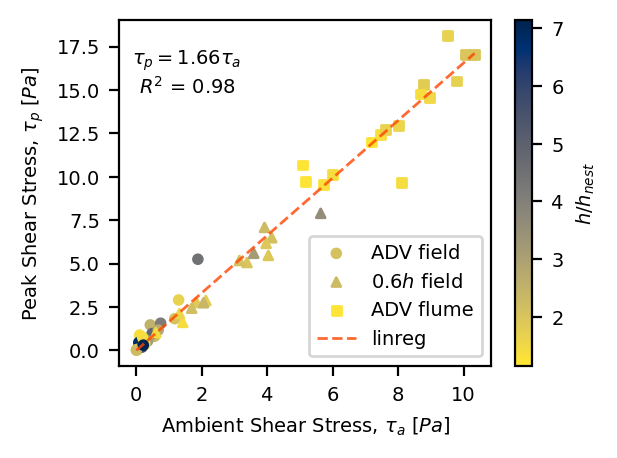

In [4]:
# ------------------------------------------------------
# Collect the shear-stress data and split by measurement type
# ------------------------------------------------------
x_str = 'tau_a_Usq_Pa'
y_str = 'tau_p_Usq_Pa'
xyz = make_xyz(amp_df_master, x_str, y_str)

# split into ADV field, 0.6h synthetic field, and flume subsets
xyz_ADV = xyz[~xyz['Station'].str.contains('Flume|Synthetic')]
xyz_synth = xyz[xyz['Station'].str.contains('Synthetic')]
xyz_flume = xyz[xyz['Station'].str.contains('Flume')]

# the full-dataset h/n range sets the shared colorbar limits
z_full = col(xyz, 'z')

# --- composite: fit all data through the origin and plot ---
model, r_sq = fit_through_origin(col(xyz, 'x'), col(xyz, 'y'))
series = [
    (col(xyz_ADV, 'x'),   col(xyz_ADV, 'y'),   col(xyz_ADV, 'z'),   'o', 'ADV field'),
    (col(xyz_synth, 'x'), col(xyz_synth, 'y'), col(xyz_synth, 'z'), '^', '$0.6h$ field'),
    (col(xyz_flume, 'x'), col(xyz_flume, 'y'), col(xyz_flume, 'z'), 's', 'ADV flume'),
]
plot_stress_amp(series, col(xyz, 'x'), z_full, model, r_sq,
                r'Ambient Shear Stress, $\tau_a$ [$Pa$]',
                r'Peak Shear Stress, $\tau_p$ [$Pa$]',
                r'$\tau_p = $', r'$\tau_a$',
                y_str+'_composite')

### Flume only

slope b=  [1.67142852]
intercept =  0.0
R^2 =  0.7752330742731062


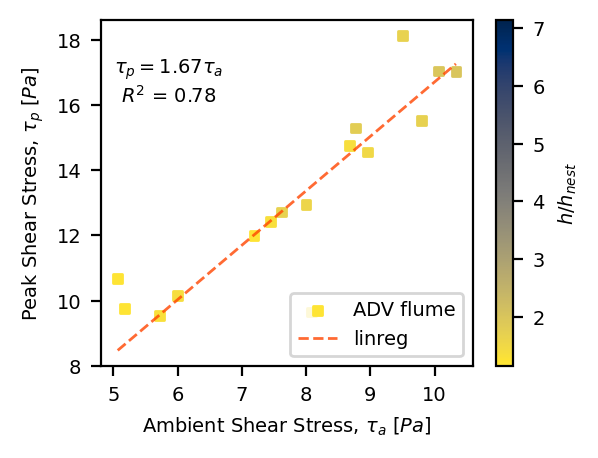

In [5]:
# --- flume only: fit the flume data alone through the origin and plot ---
model, r_sq = fit_through_origin(col(xyz_flume, 'x'), col(xyz_flume, 'y'))
series = [(col(xyz_flume, 'x'), col(xyz_flume, 'y'), col(xyz_flume, 'z'), 's', 'ADV flume')]
plot_stress_amp(series, col(xyz_flume, 'x'), z_full, model, r_sq,
                r'Ambient Shear Stress, $\tau_a$ [$Pa$]',
                r'Peak Shear Stress, $\tau_p$ [$Pa$]',
                r'$\tau_p = $', r'$\tau_a$',
                y_str+'_justADVflume')

## Shields stress amplification

Same origin-forced regression as above, but for the dimensionless Shields stress $\tau^*$. Points are colored by relative depth $h/n$.

slope b=  [1.6429101]
intercept =  0.0
R^2 =  0.971364604744321


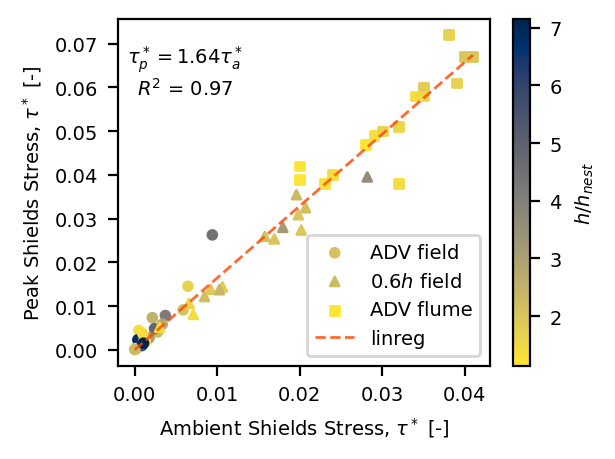

In [6]:
# ------------------------------------------------------
# Collect the Shields-stress data and split by measurement type
# ------------------------------------------------------
x_str = 'tau_st_a_Usq'
y_str = 'tau_st_p_Usq'
xyz = make_xyz(amp_df_master, x_str, y_str)

xyz_ADV = xyz[~xyz['Station'].str.contains('Flume|Synthetic')]
xyz_synth = xyz[xyz['Station'].str.contains('Synthetic')]
xyz_flume = xyz[xyz['Station'].str.contains('Flume')]

z_full = col(xyz, 'z')

# --- composite: fit all data through the origin and plot ---
model, r_sq = fit_through_origin(col(xyz, 'x'), col(xyz, 'y'))
series = [
    (col(xyz_ADV, 'x'),   col(xyz_ADV, 'y'),   col(xyz_ADV, 'z'),   'o', 'ADV field'),
    (col(xyz_synth, 'x'), col(xyz_synth, 'y'), col(xyz_synth, 'z'), '^', '$0.6h$ field'),
    (col(xyz_flume, 'x'), col(xyz_flume, 'y'), col(xyz_flume, 'z'), 's', 'ADV flume'),
]
plot_stress_amp(series, col(xyz, 'x'), z_full, model, r_sq,
                r'Ambient Shields Stress, $\tau^*$ [-]',
                r'Peak Shields Stress, $\tau^*$ [-]',
                r'$\tau^*_p = $', r'$\tau^*_a$',
                y_str+'_composite')

### Flume only

slope b=  [1.66460502]
intercept =  0.0
R^2 =  0.7664015175211326


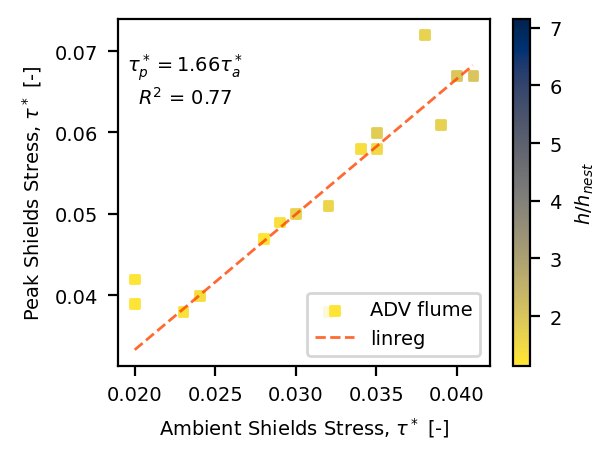

In [7]:
# --- flume only: fit the flume data alone through the origin and plot ---
model, r_sq = fit_through_origin(col(xyz_flume, 'x'), col(xyz_flume, 'y'))
series = [(col(xyz_flume, 'x'), col(xyz_flume, 'y'), col(xyz_flume, 'z'), 's', 'ADV flume')]
plot_stress_amp(series, col(xyz_flume, 'x'), z_full, model, r_sq,
                r'Ambient Shields Stress, $\tau^*$ [-]',
                r'Peak Shields Stress, $\tau^*$ [-]',
                r'$\tau^*_p = $', r'$\tau^*_a$',
                y_str+'_justADVflume')